# ml_tree_codes

本 notebook 为 `ml_tree_lec.ipynb` 生成数据、估计结果和配图。

**数据说明**：全章使用 ISLP 包内置的 `Default` 数据集，共 10,000 条观测，模拟信用卡持卡人的违约情况。

| 变量 | 类型 | 说明 |
|---|---|---|
| `default` | 二值分类（Yes/No） | 是否违约，目标变量 |
| `student` | 二值分类（Yes/No） | 是否为学生 |
| `balance` | 连续 | 信用卡月均余额（美元） |
| `income` | 连续 | 年收入（美元） |

**图片命名规则**：`ml_tree_fig{NN}_{描述}.png / .svg`

图片清单：

| 图号 | 文件名（不含扩展名） | 内容 |
|---|---|---|
| 01 | `ml_tree_fig01_data_overview` | 数据概览：balance/income 分布，按 default 着色 |
| 02 | `ml_tree_fig02_groupmean_bar` | 分组均值：按 student 分组的 balance 均值，对应虚拟变量回归 |
| 03 | `ml_tree_fig03_tree_equiv` | 简单两叶回归树与分组均值等价示意 |
| 04 | `ml_tree_fig04_reg_tree_partition` | 回归树：balance ~ income + student 的特征空间分割 |
| 05 | `ml_tree_fig05_rss_split` | 不同分裂点对应的 RSS，说明最优切分搜索 |
| 06 | `ml_tree_fig06_pruning_cv` | 剪枝：训练/CV/测试误差随叶节点数量的变化 |
| 07 | `ml_tree_fig07_cls_tree_partition` | 分类树：default 的特征空间分割 |
| 08 | `ml_tree_fig08_entropy_gini` | 熵、基尼指数、分类误差率随 p̂ 的变化曲线 |
| 09 | `ml_tree_fig09_bagging_oob` | Bagging：测试误差与 OOB 误差随树数量的变化 |
| 10 | `ml_tree_fig10_rf_vs_bag` | 随机森林 vs Bagging 测试误差对比 |
| 11 | `ml_tree_fig11_var_importance` | 变量重要性：随机森林 Gini 下降量 |
| 12 | `ml_tree_fig12_boost_shrinkage` | Boosting：不同学习率下的训练/测试误差 |
| 13 | `ml_tree_fig13_method_compare` | 四种方法测试误差横向对比 |

In [5]:
# ------------------------------------------------------------
# 0. 全局设置
# ------------------------------------------------------------

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

from sklearn.tree import (
    DecisionTreeClassifier as DTC,
    DecisionTreeRegressor as DTR,
    plot_tree,
    export_text,
)
from sklearn.ensemble import (
    RandomForestClassifier as RFC,
    RandomForestRegressor as RFR,
    GradientBoostingClassifier as GBC,
)
from sklearn.model_selection import (
    train_test_split,
    KFold,
    GridSearchCV,
    cross_val_score,
)
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import statsmodels.api as sm

warnings.filterwarnings("ignore")

# 创建输出文件夹
os.makedirs("./figs", exist_ok=True)
os.makedirs("./data", exist_ok=True)

# ------------------------------------------------------------
# 中文字体设置
# ------------------------------------------------------------
available_fonts = {f.name for f in fm.fontManager.ttflist}
font_candidates = [
    "SimHei",
    "Microsoft YaHei",
    "Noto Sans CJK SC",
    "Noto Sans CJK JP",
    "WenQuanYi Micro Hei",
    "Arial Unicode MS",
    "DejaVu Sans",
]
FONT_FAMILY = next((f for f in font_candidates if f in available_fonts), "DejaVu Sans")

plt.rcParams["font.sans-serif"] = [FONT_FAMILY]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.dpi": 150,
})

# 全局配色：违约=橙色，未违约=钢蓝
COLOR_DEFAULT = "#E07B39"   # 违约 Yes
COLOR_NO      = "#4878CF"   # 未违约 No
COLOR_TREE    = "#2E8B57"   # 树结构辅助色

RNG = np.random.default_rng(2026)

print(f"当前使用字体: {FONT_FAMILY}")

当前使用字体: SimHei


In [6]:
# ------------------------------------------------------------
# 1. 载入并预处理 Default 数据集
# ------------------------------------------------------------

# 优先从 ISLP 包载入；若未安装，则从 CSV 读取
try:
    from ISLP import load_data
    df = load_data("Default")
    print("数据来源：ISLP 包")
except ImportError:
    df = pd.read_csv("./data/Default.csv")
    print("数据来源：本地 CSV")

# 统一列名为小写
df.columns = df.columns.str.lower()

# 将分类变量转为 0/1 整数，方便后续建模
# default: Yes=1, No=0
# student: Yes=1, No=0
df["default_bin"] = (df["default"] == "Yes").astype(int)
df["student_bin"] = (df["student"] == "Yes").astype(int)

# 保存处理后的数据
df.to_csv("./data/default_processed.csv", index=False, encoding="utf-8-sig")

print(f"\n样本量: {len(df)}")
print(f"违约率: {df['default_bin'].mean():.2%}")
print(f"学生比例: {df['student_bin'].mean():.2%}")
print("\n描述统计：")
print(df[["balance", "income", "default_bin", "student_bin"]].describe().round(2))

数据来源：本地 CSV

样本量: 10000
违约率: 3.33%
学生比例: 29.44%

描述统计：
        balance    income  default_bin  student_bin
count  10000.00  10000.00     10000.00     10000.00
mean     835.37  33516.98         0.03         0.29
std      483.71  13336.64         0.18         0.46
min        0.00    771.97         0.00         0.00
25%      481.73  21340.46         0.00         0.00
50%      823.64  34552.64         0.00         0.00
75%     1166.31  43807.73         0.00         1.00
max     2654.32  73554.23         1.00         1.00


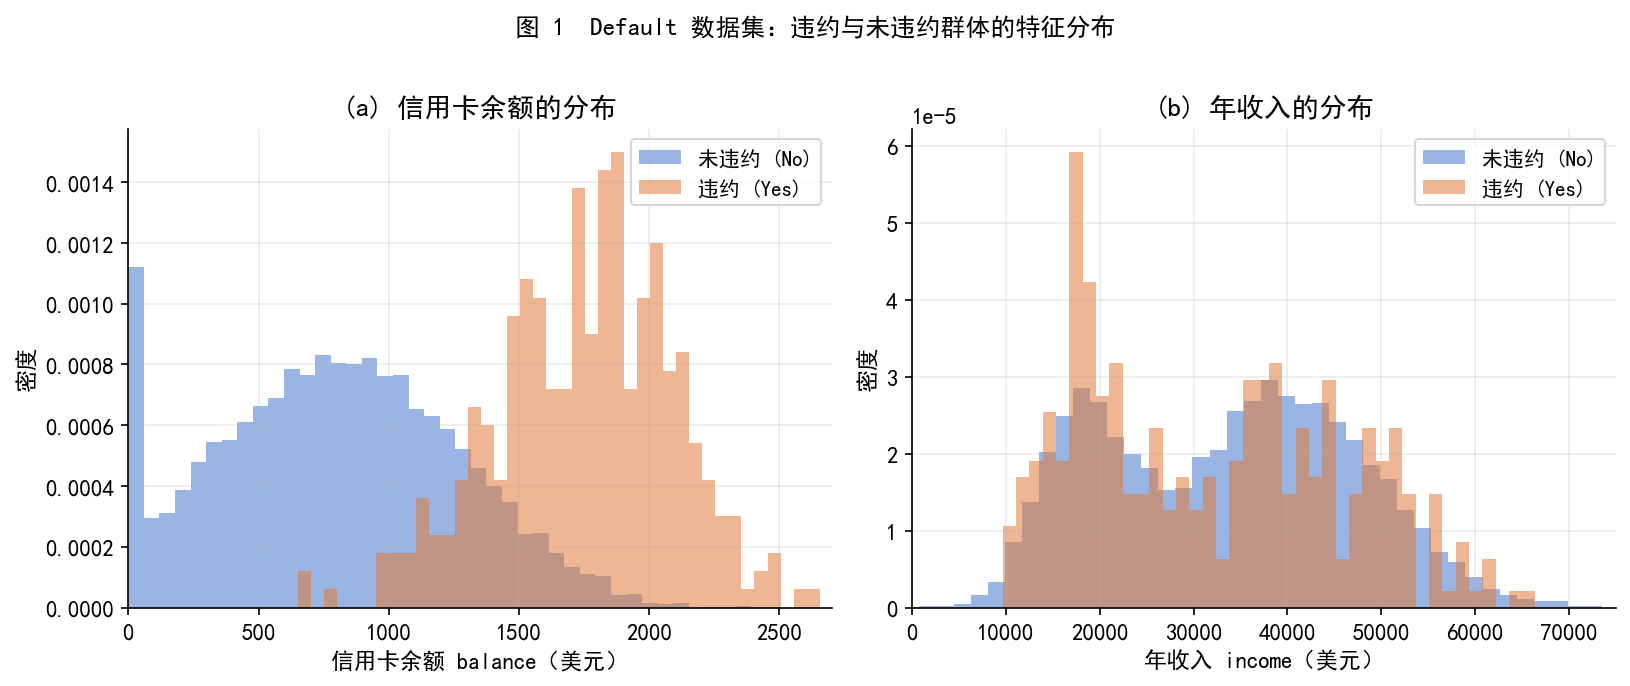

In [7]:
# ------------------------------------------------------------
# 图 01：数据概览
# ml_tree_fig01_data_overview
# 上方：balance 分布（按违约状态着色）
# 下方：income 分布（按违约状态着色）
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, var, label, xlim in zip(
    axes,
    ["balance", "income"],
    ["信用卡余额 balance（美元）", "年收入 income（美元）"],
    [(0, 2700), (0, 75000)],
):
    for val, color, name in [
        ("No",  COLOR_NO,      "未违约 (No)"),
        ("Yes", COLOR_DEFAULT, "违约 (Yes)"),
    ]:
        sub = df.loc[df["default"] == val, var]
        ax.hist(
            sub, bins=40, alpha=0.55, color=color,
            label=name, density=True
        )
    ax.set_xlabel(label)
    ax.set_ylabel("密度")
    ax.set_xlim(xlim)
    ax.legend(fontsize=10)

axes[0].set_title("(a) 信用卡余额的分布")
axes[1].set_title("(b) 年收入的分布")

fig.suptitle("图 1  Default 数据集：违约与未违约群体的特征分布",
             fontsize=12, y=1.01)
fig.tight_layout()
fig.savefig("./figs/ml_tree_fig01_data_overview.png", dpi=300, bbox_inches="tight")
fig.savefig("./figs/ml_tree_fig01_data_overview.svg", bbox_inches="tight")
plt.show()

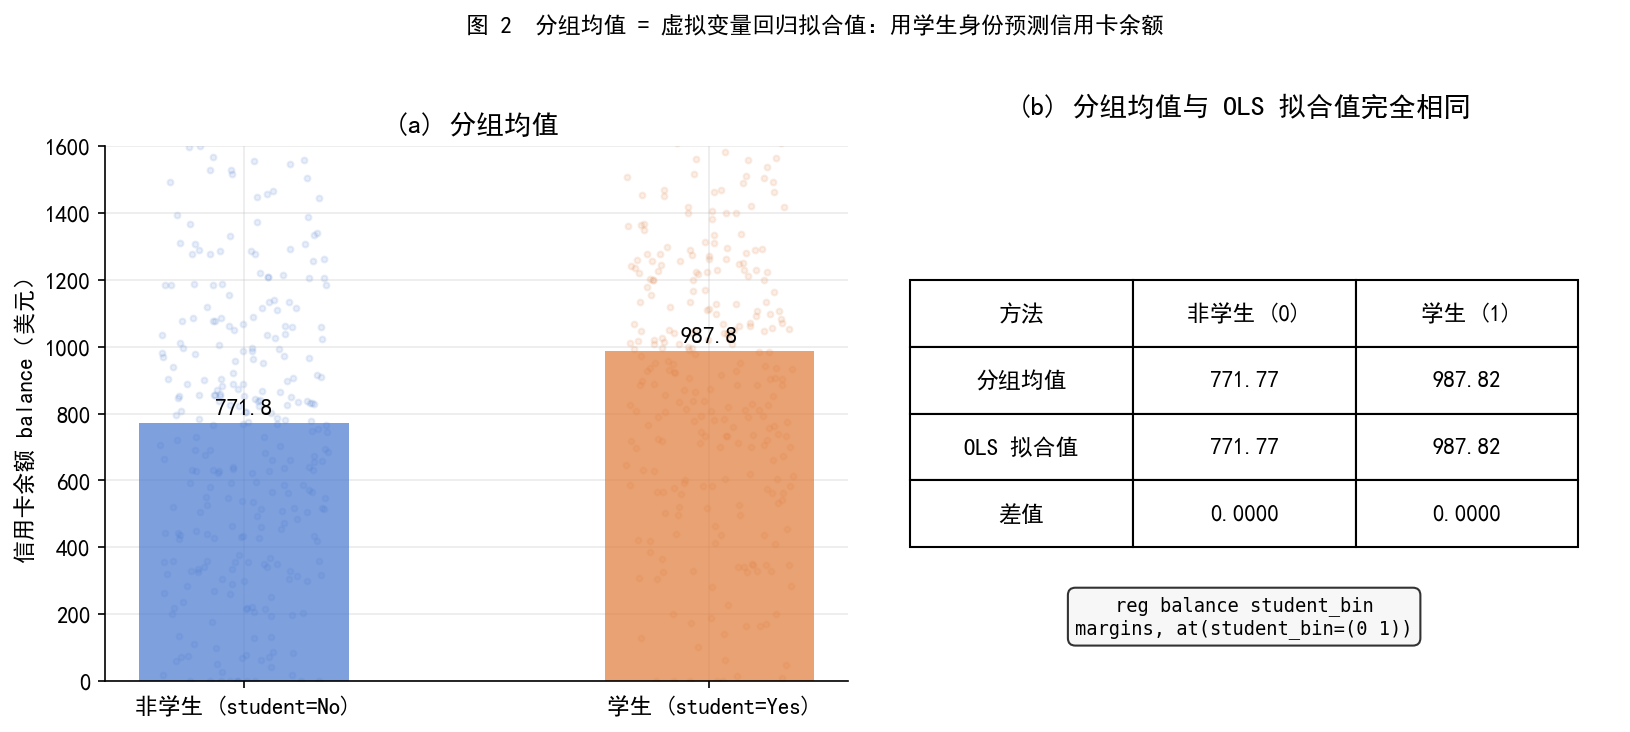

非学生 balance 均值: 771.77
学生   balance 均值: 987.82
OLS 截距 (非学生预测值): 771.77
OLS 斜率 (student_bin 系数): 216.05


In [8]:
# ------------------------------------------------------------
# 图 02：分组均值与虚拟变量回归等价性
# ml_tree_fig02_groupmean_bar
# 左：按 student 分组的 balance 均值（条形图 + 散点抖动）
# 右：OLS 回归拟合值与分组均值的数值对比
# ------------------------------------------------------------

# 分组均值
group_means = df.groupby("student")["balance"].mean()
mean_no  = group_means["No"]
mean_yes = group_means["Yes"]

# OLS: balance ~ student_bin
X_ols = sm.add_constant(df["student_bin"])
ols_res = sm.OLS(df["balance"], X_ols).fit()
pred_no  = ols_res.predict(pd.DataFrame({"const": [1], "student_bin": [0]}))[0]
pred_yes = ols_res.predict(pd.DataFrame({"const": [1], "student_bin": [1]}))[0]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

# 左图：条形 + 散点抖动
ax = axes[0]
categories = ["非学生 (student=No)", "学生 (student=Yes)"]
means_vals = [mean_no, mean_yes]
colors_bar = [COLOR_NO, COLOR_DEFAULT]

bars = ax.bar(categories, means_vals, color=colors_bar, alpha=0.7, width=0.45, zorder=2)

# 散点抖动（子样本，避免图太密）
for i, (cat_val, color) in enumerate([("No", COLOR_NO), ("Yes", COLOR_DEFAULT)]):
    sub = df.loc[df["student"] == cat_val, "balance"].sample(300, random_state=42)
    jitter = RNG.uniform(-0.18, 0.18, len(sub))
    ax.scatter(i + jitter, sub, alpha=0.12, s=8, color=color, zorder=1)

# 标注均值
for bar, val in zip(bars, means_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 15, f"{val:.1f}",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax.set_ylabel("信用卡余额 balance（美元）")
ax.set_title("(a) 分组均值")
ax.set_ylim(0, 1600)

# 右图：分组均值 vs OLS 拟合值对比表（用文本图）
ax2 = axes[1]
ax2.axis("off")

table_data = [
    ["方法", "非学生 (0)", "学生 (1)"],
    ["分组均值",      f"{mean_no:.2f}",  f"{mean_yes:.2f}"],
    ["OLS 拟合值",    f"{pred_no:.2f}",  f"{pred_yes:.2f}"],
    ["差值",
     f"{abs(mean_no - pred_no):.4f}",
     f"{abs(mean_yes - pred_yes):.4f}"],
]

tbl = ax2.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    cellLoc="center",
    loc="center",
    bbox=[0.05, 0.25, 0.9, 0.5],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.8)

ax2.set_title("(b) 分组均值与 OLS 拟合值完全相同", pad=15)
ax2.text(
    0.5, 0.08,
    "reg balance student_bin\nmargins, at(student_bin=(0 1))",
    transform=ax2.transAxes, ha="center", va="bottom",
    fontsize=9, family="monospace",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#f5f5f5", alpha=0.8)
)

fig.suptitle("图 2  分组均值 = 虚拟变量回归拟合值：用学生身份预测信用卡余额",
             fontsize=11, y=1.01)
fig.tight_layout()
fig.savefig("./figs/ml_tree_fig02_groupmean_bar.png", dpi=300, bbox_inches="tight")
fig.savefig("./figs/ml_tree_fig02_groupmean_bar.svg", bbox_inches="tight")
plt.show()

print(f"非学生 balance 均值: {mean_no:.2f}")
print(f"学生   balance 均值: {mean_yes:.2f}")
print(f"OLS 截距 (非学生预测值): {ols_res.params['const']:.2f}")
print(f"OLS 斜率 (student_bin 系数): {ols_res.params['student_bin']:.2f}")

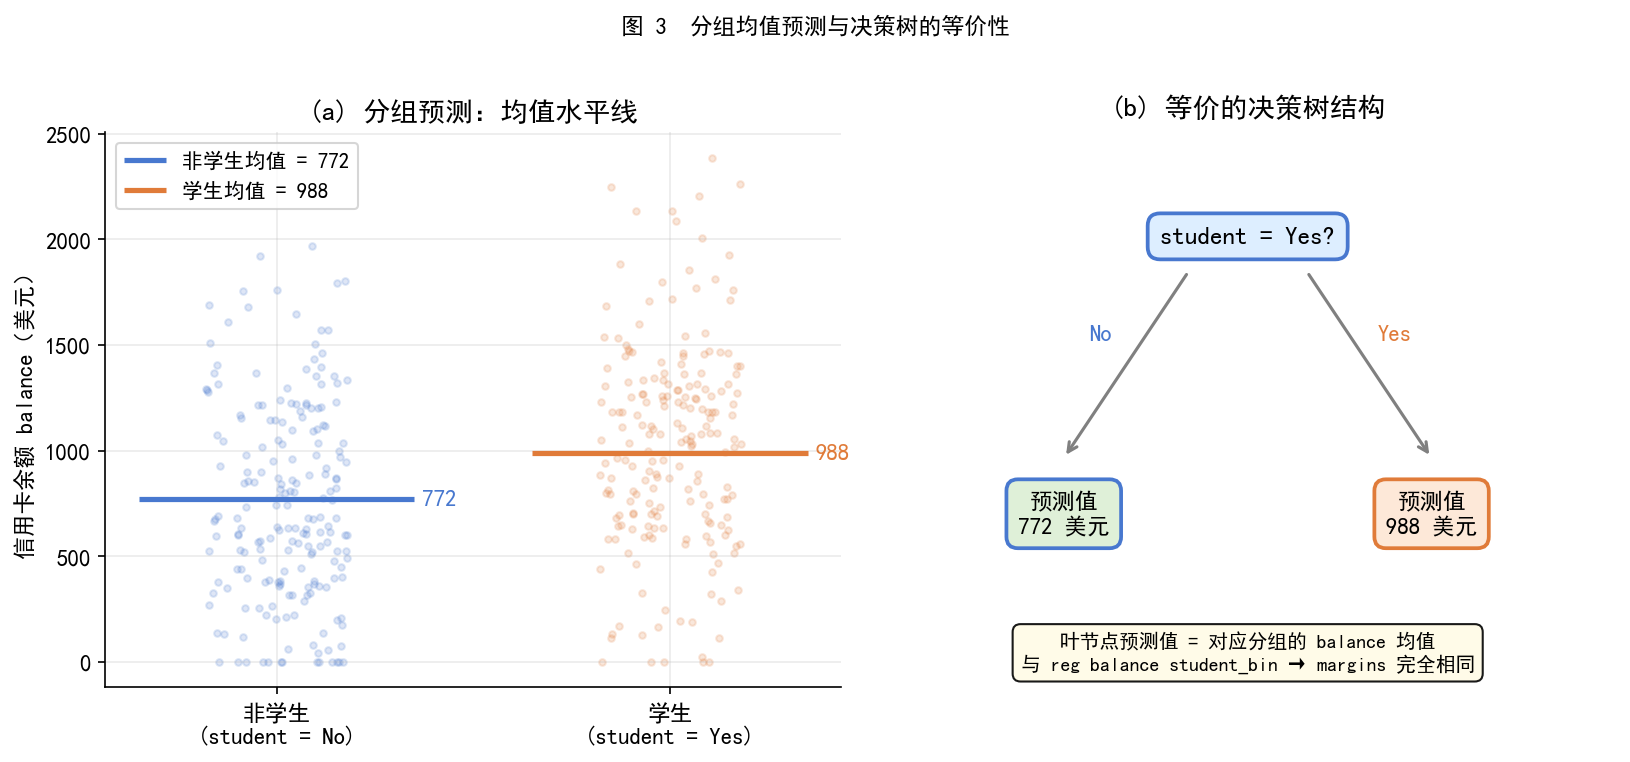

In [9]:
# ------------------------------------------------------------
# 图 03：分组均值 = 两叶决策树等价示意图
# ml_tree_fig03_tree_equiv
# 左：散点图，按 student 分组，标出分组均值水平线
# 右：手绘风格的两叶树示意图（用 matplotlib 绘制，不用 sklearn plot_tree）
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# --- 左图：散点 + 分组均值水平线 ---
ax = axes[0]
for i, (cat_val, color, label, xpos) in enumerate([
    ("No",  COLOR_NO,      "非学生", 0),
    ("Yes", COLOR_DEFAULT, "学生",   1),
]):
    sub = df.loc[df["student"] == cat_val, "balance"].sample(200, random_state=7)
    jitter = RNG.uniform(-0.18, 0.18, len(sub))
    ax.scatter(xpos + jitter, sub, alpha=0.18, s=10, color=color, zorder=1)
    m = group_means[cat_val]
    ax.hlines(m, xpos - 0.35, xpos + 0.35,
              colors=color, linewidths=2.5, zorder=3,
              label=f"{label}均值 = {m:.0f}")
    ax.text(xpos + 0.37, m, f"{m:.0f}",
            va="center", ha="left", fontsize=11, color=color, fontweight="bold")

ax.set_xticks([0, 1])
ax.set_xticklabels(["非学生\n(student = No)", "学生\n(student = Yes)"])
ax.set_ylabel("信用卡余额 balance（美元）")
ax.set_title("(a) 分组预测：均值水平线")
ax.legend(fontsize=10, loc="upper left")

# --- 右图：手绘两叶树结构 ---
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 8)
ax2.axis("off")
ax2.set_title("(b) 等价的决策树结构", pad=8)

# 根节点
root_box = dict(boxstyle="round,pad=0.5", facecolor="#ddeeff", edgecolor="#4878CF", lw=1.8)
ax2.text(5, 6.5, "student = Yes?",
         ha="center", va="center", fontsize=12, bbox=root_box)

# 左叶节点（No 分支）
leaf_box_no = dict(boxstyle="round,pad=0.5", facecolor="#dff0d8", edgecolor=COLOR_NO, lw=1.8)
ax2.text(2.5, 2.5, f"预测值\n{mean_no:.0f} 美元",
         ha="center", va="center", fontsize=11, bbox=leaf_box_no)

# 右叶节点（Yes 分支）
leaf_box_yes = dict(boxstyle="round,pad=0.5", facecolor="#fde8d8", edgecolor=COLOR_DEFAULT, lw=1.8)
ax2.text(7.5, 2.5, f"预测值\n{mean_yes:.0f} 美元",
         ha="center", va="center", fontsize=11, bbox=leaf_box_yes)

# 连接线
ax2.annotate("", xy=(2.5, 3.3), xytext=(4.2, 6.0),
             arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
ax2.annotate("", xy=(7.5, 3.3), xytext=(5.8, 6.0),
             arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))

# 分支标注
ax2.text(3.0, 5.0, "No",  ha="center", fontsize=11, color=COLOR_NO, fontweight="bold")
ax2.text(7.0, 5.0, "Yes", ha="center", fontsize=11, color=COLOR_DEFAULT, fontweight="bold")

# 底部注释
ax2.text(5, 0.5,
         "叶节点预测值 = 对应分组的 balance 均值\n与 reg balance student_bin → margins 完全相同",
         ha="center", va="center", fontsize=9.5,
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#fffbe6", alpha=0.9))

fig.suptitle("图 3  分组均值预测与决策树的等价性", fontsize=11, y=1.01)
fig.tight_layout()
fig.savefig("./figs/ml_tree_fig03_tree_equiv.png", dpi=300, bbox_inches="tight")
fig.savefig("./figs/ml_tree_fig03_tree_equiv.svg", bbox_inches="tight")
plt.show()

## 为什么不用线性模型？

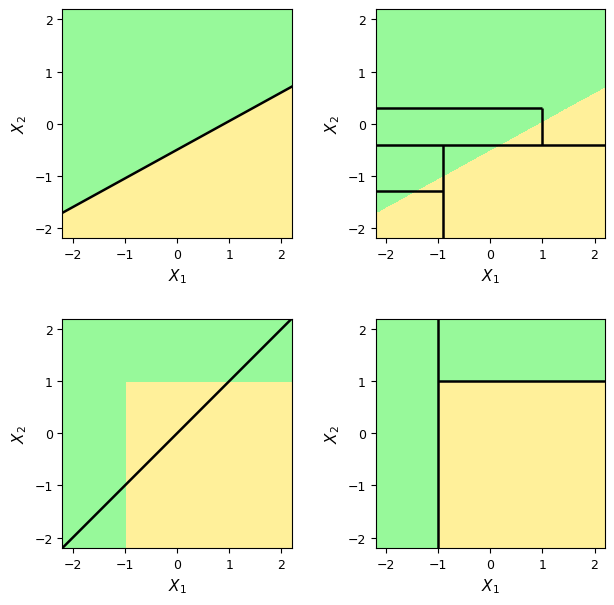

In [ ]:
# -*- coding: utf-8 -*-
"""
绘制线性分类器与决策树分类边界的对比图。
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ── 1. 基本设置 ─────────────────────────────────────────────
os.makedirs("./figs", exist_ok=True)

# 图形颜色：0 表示黄色区域，1 表示绿色区域
YELLOW = "#FFF09A"
GREEN = "#97F99A"
CMAP = ListedColormap([YELLOW, GREEN])

# 坐标范围
x_min, x_max = -2.2, 2.2
y_min, y_max = -2.2, 2.2

# 用网格点生成二维平面
x1 = np.linspace(x_min, x_max, 500)
x2 = np.linspace(y_min, y_max, 500)
X1, X2 = np.meshgrid(x1, x2)

# ── 2. 构造真实的分类区域 ──────────────────────────────────
Z_linear = (X2 >= 0.55 * X1 - 0.50).astype(int)
Z_nonlinear = np.where((X1 >= -1.0) & (X2 <= 1.0), 0, 1)

# ── 3. 辅助函数 ────────────────────────────────────────────
def format_axis(ax):
    """统一设置坐标轴格式。"""
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"$X_1$", fontsize=11)
    ax.set_ylabel(r"$X_2$", fontsize=11)
    ax.set_xticks([-2, -1, 0, 1, 2])
    ax.set_yticks([-2, -1, 0, 1, 2])
    ax.tick_params(axis="both", labelsize=9, direction="out")
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

def draw_region(ax, Z):
    """绘制分类区域。"""
    ax.contourf(X1, X2, Z, levels=[-0.5, 0.5, 1.5], cmap=CMAP, alpha=1.0)

# ── 4. 绘制图形 ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(7.2, 7.0))

xx = np.linspace(x_min, x_max, 200)

# 左上：线性边界 + 线性模型
axes[0, 0].contourf(X1, X2, Z_linear, levels=[-0.5, 0.5, 1.5], cmap=CMAP, alpha=1.0)
axes[0, 0].plot(xx, 0.55 * xx - 0.50, color="black", linewidth=1.8)
format_axis(axes[0, 0])

# 右上：线性边界 + 决策树模型
axes[0, 1].contourf(X1, X2, Z_linear, levels=[-0.5, 0.5, 1.5], cmap=CMAP, alpha=1.0)
axes[0, 1].hlines(y=-0.40, xmin=x_min, xmax=x_max, color="black", linewidth=1.8)
axes[0, 1].vlines(x=-0.90, ymin=y_min, ymax=-0.40, color="black", linewidth=1.8)
axes[0, 1].hlines(y=-1.30, xmin=x_min, xmax=-0.90, color="black", linewidth=1.8)
axes[0, 1].hlines(y=0.30, xmin=x_min, xmax=1.00, color="black", linewidth=1.8)
axes[0, 1].vlines(x=1.00, ymin=-0.40, ymax=0.30, color="black", linewidth=1.8)
format_axis(axes[0, 1])

# 左下：非线性边界 + 线性模型
axes[1, 0].contourf(X1, X2, Z_nonlinear, levels=[-0.5, 0.5, 1.5], cmap=CMAP, alpha=1.0)
axes[1, 0].plot(xx, xx, color="black", linewidth=1.8)
format_axis(axes[1, 0])

# 右下：非线性边界 + 决策树模型
axes[1, 1].contourf(X1, X2, Z_nonlinear, levels=[-0.5, 0.5, 1.5], cmap=CMAP, alpha=1.0)
axes[1, 1].vlines(x=-1.00, ymin=y_min, ymax=y_max, color="black", linewidth=1.8)
axes[1, 1].hlines(y=1.00, xmin=-1.00, xmax=x_max, color="black", linewidth=1.8)
format_axis(axes[1, 1])

plt.subplots_adjust(wspace=0.28, hspace=0.35)
fig.savefig("./figs/ml_tree_fig02_linear_tree_boundary.png", dpi=300, bbox_inches="tight")
fig.savefig("./figs/ml_tree_fig02_linear_tree_boundary.svg", bbox_inches="tight")
plt.show()


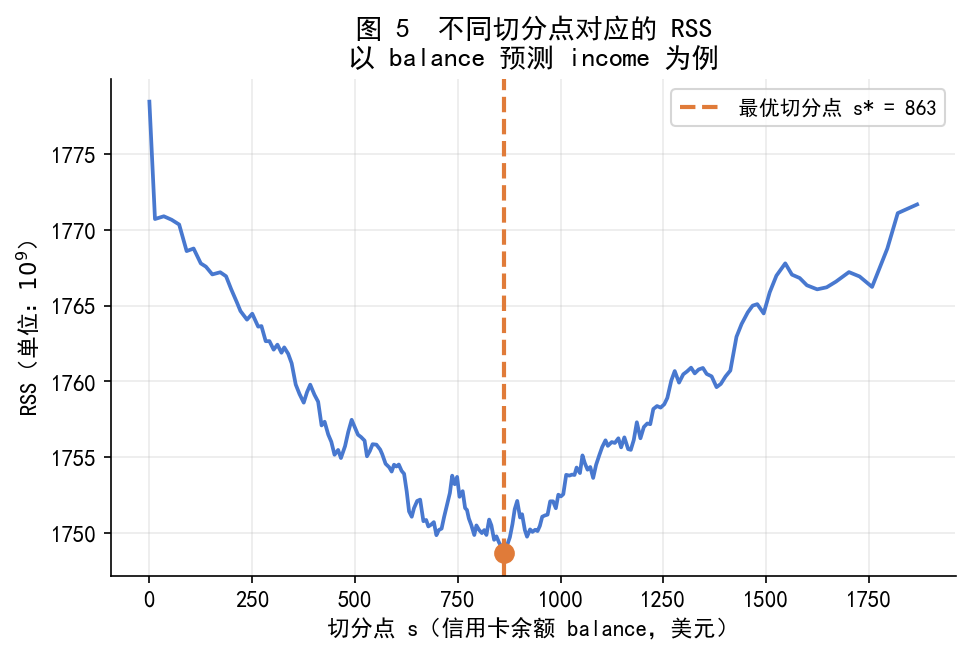

最优切分点: balance = 863.33，RSS = 1.749e+12


In [14]:
# ------------------------------------------------------------
# 图 05：不同切分点对应的 RSS（说明最优切分搜索过程）
# ml_tree_fig05_rss_split
# 以 balance 预测 income 为例，遍历切分点，画出 RSS 曲线
# ------------------------------------------------------------

X_bal = df["balance"].values
y_inc = df["income"].values

# 取分位数作为候选切分点，避免遍历 10000 个点
cutpoints = np.quantile(X_bal, np.linspace(0.02, 0.98, 200))

rss_list = []
for s in cutpoints:
    left  = y_inc[X_bal < s]
    right = y_inc[X_bal >= s]
    rss = 0.0
    if len(left)  > 0: rss += np.sum((left  - left.mean())  ** 2)
    if len(right) > 0: rss += np.sum((right - right.mean()) ** 2)
    rss_list.append(rss)

rss_arr = np.array(rss_list)
best_idx = np.argmin(rss_arr)
best_cut = cutpoints[best_idx]

fig, ax = plt.subplots(figsize=(6.6, 4.5))
ax.plot(cutpoints, rss_arr / 1e9, color=COLOR_NO, lw=1.8)
ax.axvline(best_cut, color=COLOR_DEFAULT, lw=2, linestyle="--",
           label=f"最优切分点 s* = {best_cut:.0f}")
ax.scatter([best_cut], [rss_arr[best_idx] / 1e9],
           color=COLOR_DEFAULT, s=80, zorder=5)
ax.set_xlabel("切分点 s（信用卡余额 balance，美元）")
ax.set_ylabel("RSS（单位：$10^9$）")
ax.set_title("图 5  不同切分点对应的 RSS\n以 balance 预测 income 为例")
ax.legend(fontsize=10)
fig.tight_layout()
fig.savefig("./figs/ml_tree_fig05_rss_split.png", dpi=300, bbox_inches="tight")
fig.savefig("./figs/ml_tree_fig05_rss_split.svg", bbox_inches="tight")
plt.show()
print(f"最优切分点: balance = {best_cut:.2f}，RSS = {rss_arr[best_idx]:.3e}")

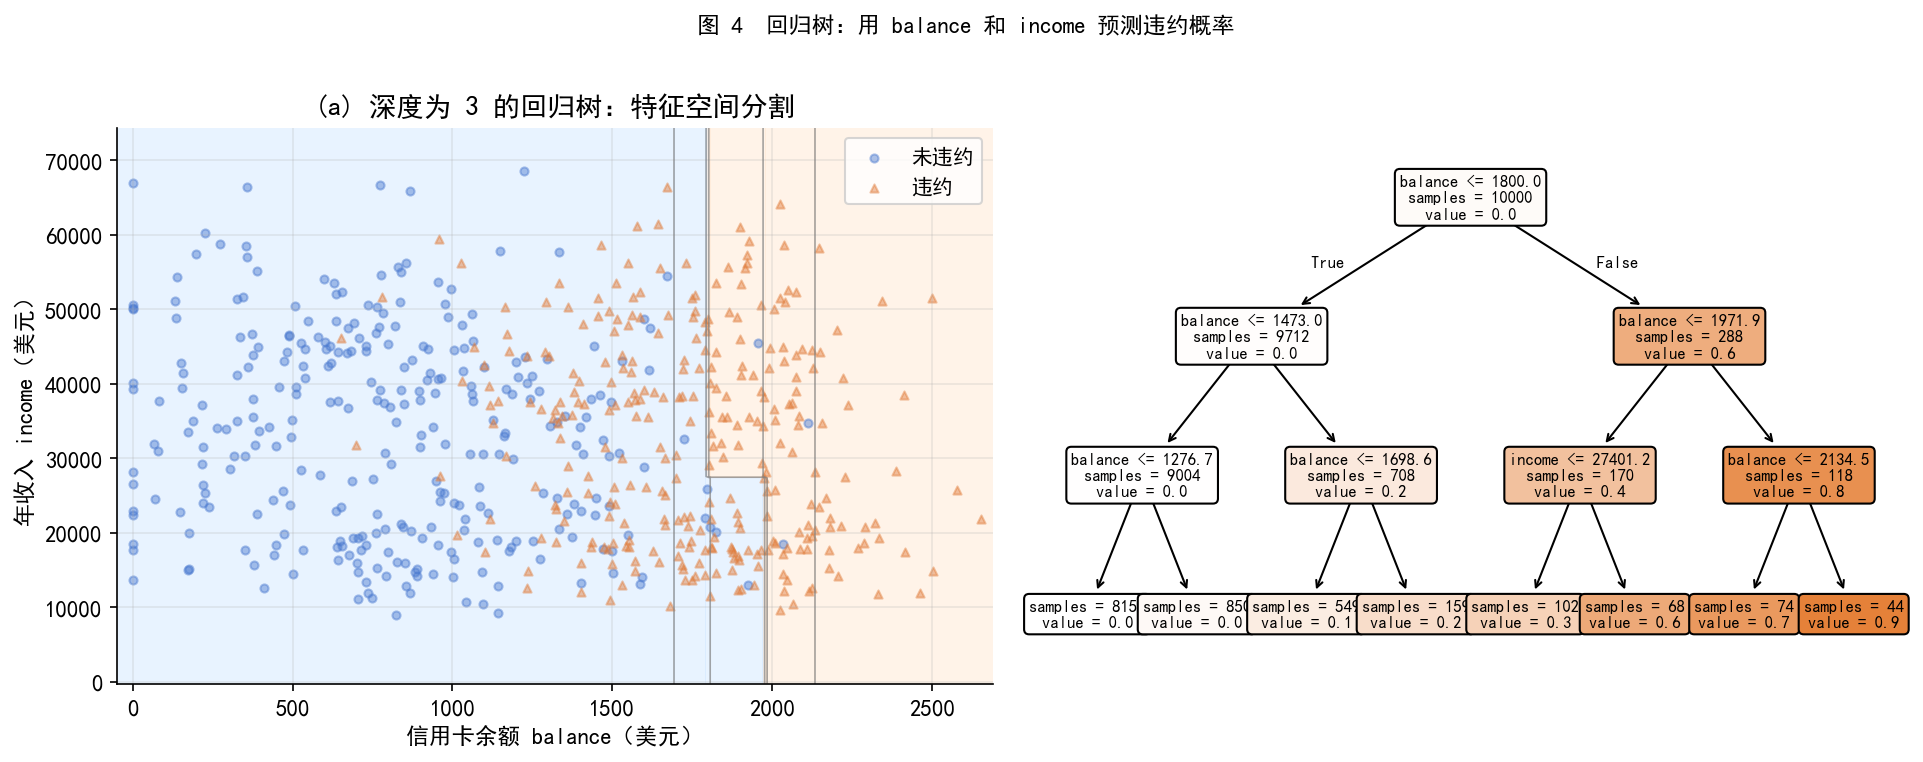

In [11]:
# ------------------------------------------------------------
# 图 04：回归树特征空间分割
# ml_tree_fig04_reg_tree_partition
# 用 balance 和 income 预测 default_bin（概率），展示分割区域
# ------------------------------------------------------------

# 用两个连续变量拟合深度为 3 的回归树
X_reg = df[["balance", "income"]].values
y_reg = df["default_bin"].values

reg_tree = DTR(max_depth=3, random_state=42)
reg_tree.fit(X_reg, y_reg)

# 构建网格用于可视化分割区域
h = 20  # 网格步长（美元）
xx, yy = np.meshgrid(
    np.arange(X_reg[:, 0].min() - 50,  X_reg[:, 0].max() + 50,  h),
    np.arange(X_reg[:, 1].min() - 1000, X_reg[:, 1].max() + 1000, 200),
)
Z = reg_tree.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左图：特征空间分割区域
ax = axes[0]
cmap_region = ListedColormap(["#cce5ff", "#ffe5cc"])
ax.contourf(xx, yy, Z, alpha=0.45, cmap=cmap_region, levels=10)

# 绘制分割边界线
ax.contour(xx, yy, Z, colors="gray", linewidths=0.8, alpha=0.7)

# 散点（子样本）
for val, color, marker in [(0, COLOR_NO, "o"), (1, COLOR_DEFAULT, "^")]:
    mask = y_reg == val
    idx = np.where(mask)[0]
    idx_sample = RNG.choice(idx, min(300, mask.sum()), replace=False)
    ax.scatter(X_reg[idx_sample, 0], X_reg[idx_sample, 1],
               c=color, marker=marker, alpha=0.45, s=15,
               label="违约" if val == 1 else "未违约")

ax.set_xlabel("信用卡余额 balance（美元）")
ax.set_ylabel("年收入 income（美元）")
ax.set_title("(a) 深度为 3 的回归树：特征空间分割")
ax.legend(fontsize=10)

# 右图：树结构图
ax2 = axes[1]
ax2.set_title("(b) 对应的树结构")
plot_tree(
    reg_tree,
    feature_names=["balance", "income"],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax2,
    impurity=False,
    precision=1,
)

fig.suptitle("图 4  回归树：用 balance 和 income 预测违约概率",
             fontsize=11, y=1.01)
fig.tight_layout()
fig.savefig("./figs/ml_tree_fig04_reg_tree_partition.png", dpi=300, bbox_inches="tight")
fig.savefig("./figs/ml_tree_fig04_reg_tree_partition.svg", bbox_inches="tight")
plt.show()

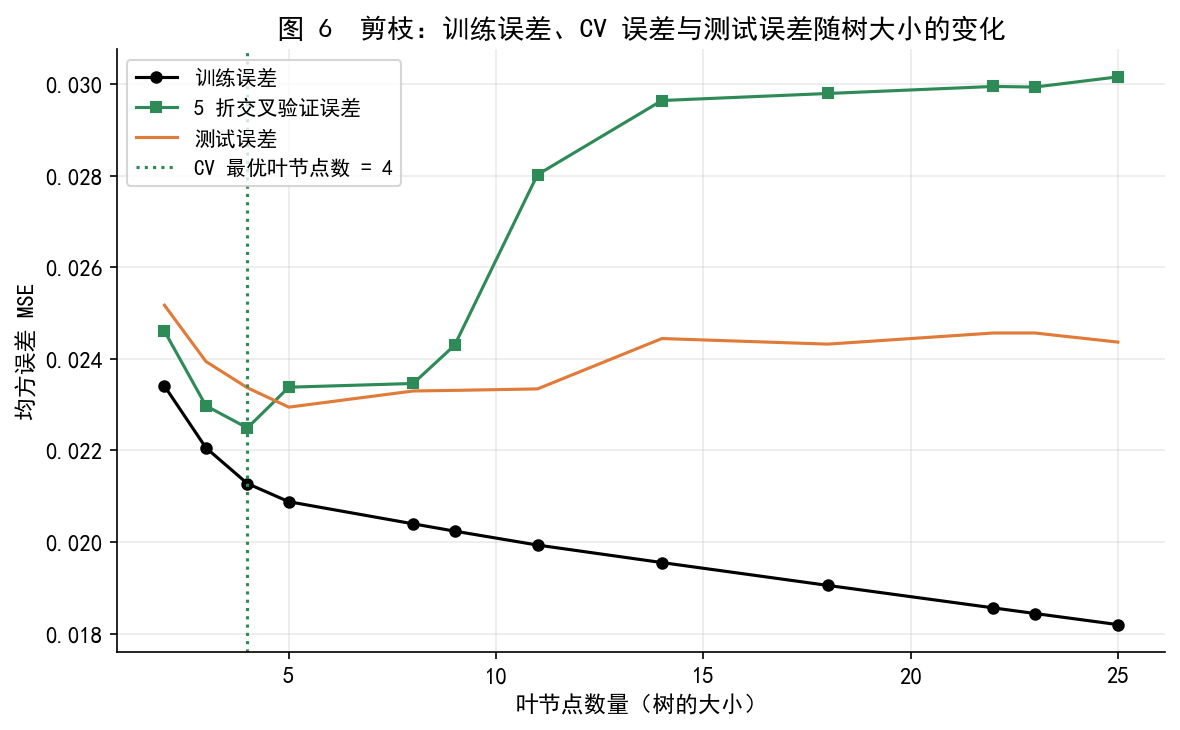

CV 最优叶节点数: 4


In [16]:
# ------------------------------------------------------------
# 图 06：剪枝 — 训练/CV/测试误差随叶节点数量的变化
# ml_tree_fig06_pruning_cv
# ------------------------------------------------------------

# 使用 balance 和 income 预测 default_bin（回归树，MSE）
X_p = df[["balance", "income"]].values
y_p = df["default_bin"].values.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X_p, y_p, test_size=0.3, random_state=42
)

# 先生长一棵完整树
full_tree = DTR(random_state=42)
full_tree.fit(X_train, y_train)

# 获取代价复杂度路径
ccp_path = full_tree.cost_complexity_pruning_path(X_train, y_train)
alphas = ccp_path.ccp_alphas[:-1]  # 去掉最后一个（只剩根节点）

# 对每个 alpha 值：拟合剪枝树，记录叶节点数、训练误差、测试误差
n_leaves_list, train_mse_list, test_mse_list = [], [], []
for alpha in alphas:
    t = DTR(ccp_alpha=alpha, random_state=42)
    t.fit(X_train, y_train)
    n_leaves_list.append(t.get_n_leaves())
    train_mse_list.append(np.mean((y_train - t.predict(X_train)) ** 2))
    test_mse_list.append(np.mean((y_test  - t.predict(X_test))  ** 2))

# CV 误差（5 折）
cv_scores = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for alpha in alphas:
    t = DTR(ccp_alpha=alpha, random_state=42)
    scores = cross_val_score(t, X_train, y_train,
                             cv=kf, scoring="neg_mean_squared_error")
    cv_scores.append(-scores.mean())

# 整理为 DataFrame，按叶节点数去重取均值（多个 alpha 可能对应同样叶节点数）
df_prune = pd.DataFrame({
    "n_leaves":  n_leaves_list,
    "train_mse": train_mse_list,
    "test_mse":  test_mse_list,
    "cv_mse":    cv_scores,
}).sort_values("n_leaves").drop_duplicates(subset="n_leaves")

# 只保留叶节点数在 [1, 25] 之间的部分
df_prune = df_prune[df_prune["n_leaves"] <= 25]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_prune["n_leaves"], df_prune["train_mse"],
        "k-o", ms=5, lw=1.5, label="训练误差")
ax.plot(
    df_prune["n_leaves"], df_prune["cv_mse"],
    color=COLOR_TREE, linestyle="-", marker="s", ms=5, lw=1.5,
    label="5 折交叉验证误差"
)
ax.plot(df_prune["n_leaves"], df_prune["test_mse"],
        color=COLOR_DEFAULT, linestyle="-", ms=5, lw=1.5, label="测试误差")

# 标注 CV 最优叶节点数
best_n = df_prune.loc[df_prune["cv_mse"].idxmin(), "n_leaves"]
ax.axvline(best_n, color=COLOR_TREE, linestyle=":", lw=1.5,
           label=f"CV 最优叶节点数 = {best_n}")

ax.set_xlabel("叶节点数量（树的大小）")
ax.set_ylabel("均方误差 MSE")
ax.set_title("图 6  剪枝：训练误差、CV 误差与测试误差随树大小的变化")
ax.legend(fontsize=10)
fig.tight_layout()
fig.savefig("./figs/ml_tree_fig06_pruning_cv.png", dpi=300, bbox_inches="tight")
fig.savefig("./figs/ml_tree_fig06_pruning_cv.svg", bbox_inches="tight")
plt.show()
print(f"CV 最优叶节点数: {best_n}")

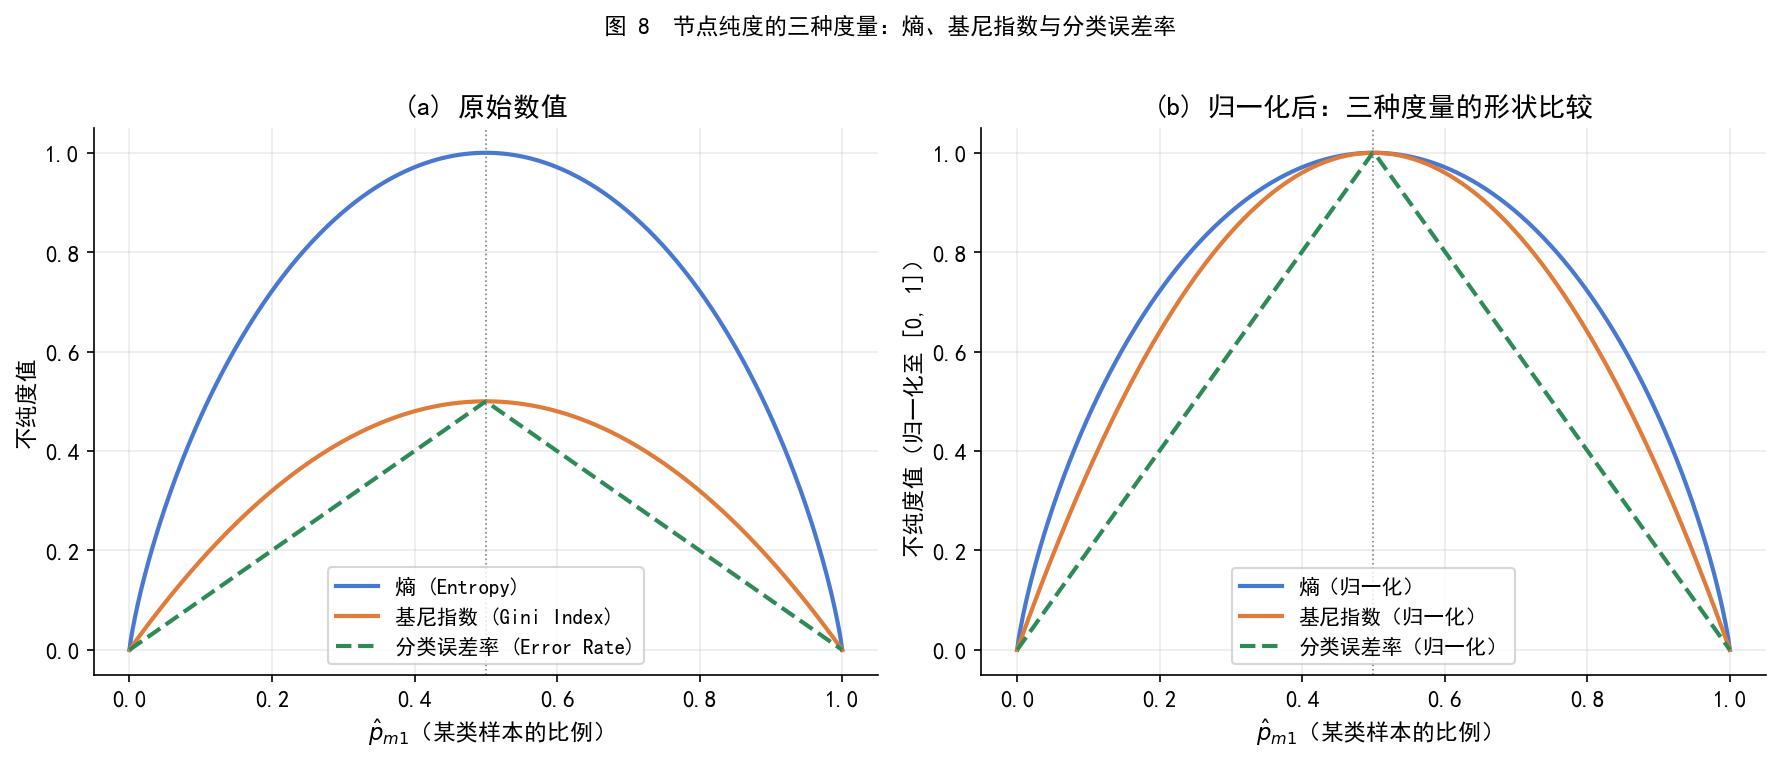

In [17]:
# ------------------------------------------------------------
# 图 08：熵、基尼指数、分类误差率曲线
# ml_tree_fig08_entropy_gini
# 横轴：p̂_m1（某类的比例），纵轴：三种纯度度量的值
# ------------------------------------------------------------

p = np.linspace(1e-6, 1 - 1e-6, 500)
q = 1 - p

entropy = -(p * np.log2(p) + q * np.log2(q))  # 用 log2 使最大值为 1，便于比较
gini    = 2 * p * q                             # 二分类基尼指数
cls_err = 1 - np.maximum(p, q)                  # 分类误差率

# 归一化，使三条曲线的最大值相同（便于视觉比较）
entropy_scaled = entropy / entropy.max()
gini_scaled    = gini    / gini.max()
cls_err_scaled = cls_err / cls_err.max()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左图：原始值
ax = axes[0]
ax.plot(p, entropy, label="熵 (Entropy)",           color=COLOR_NO,      lw=2)
ax.plot(p, gini,    label="基尼指数 (Gini Index)",  color=COLOR_DEFAULT, lw=2)
ax.plot(p, cls_err, label="分类误差率 (Error Rate)", color=COLOR_TREE,    lw=2, linestyle="--")
ax.set_xlabel("$\\hat{p}_{m1}$（某类样本的比例）")
ax.set_ylabel("不纯度值")
ax.set_title("(a) 原始数值")
ax.legend(fontsize=10)
ax.axvline(0.5, color="gray", lw=0.8, linestyle=":")

# 右图：归一化后（最大值均为 1）便于比较形状
ax2 = axes[1]
ax2.plot(p, entropy_scaled, label="熵（归一化）",          color=COLOR_NO,      lw=2)
ax2.plot(p, gini_scaled,    label="基尼指数（归一化）",     color=COLOR_DEFAULT, lw=2)
ax2.plot(p, cls_err_scaled, label="分类误差率（归一化）",   color=COLOR_TREE,    lw=2, linestyle="--")
ax2.set_xlabel("$\\hat{p}_{m1}$（某类样本的比例）")
ax2.set_ylabel("不纯度值（归一化至 [0, 1]）")
ax2.set_title("(b) 归一化后：三种度量的形状比较")
ax2.legend(fontsize=10)
ax2.axvline(0.5, color="gray", lw=0.8, linestyle=":")

fig.suptitle("图 8  节点纯度的三种度量：熵、基尼指数与分类误差率",
             fontsize=11, y=1.01)
fig.tight_layout()
fig.savefig("./figs/ml_tree_fig08_entropy_gini.png", dpi=300, bbox_inches="tight")
fig.savefig("./figs/ml_tree_fig08_entropy_gini.svg", bbox_inches="tight")
plt.show()

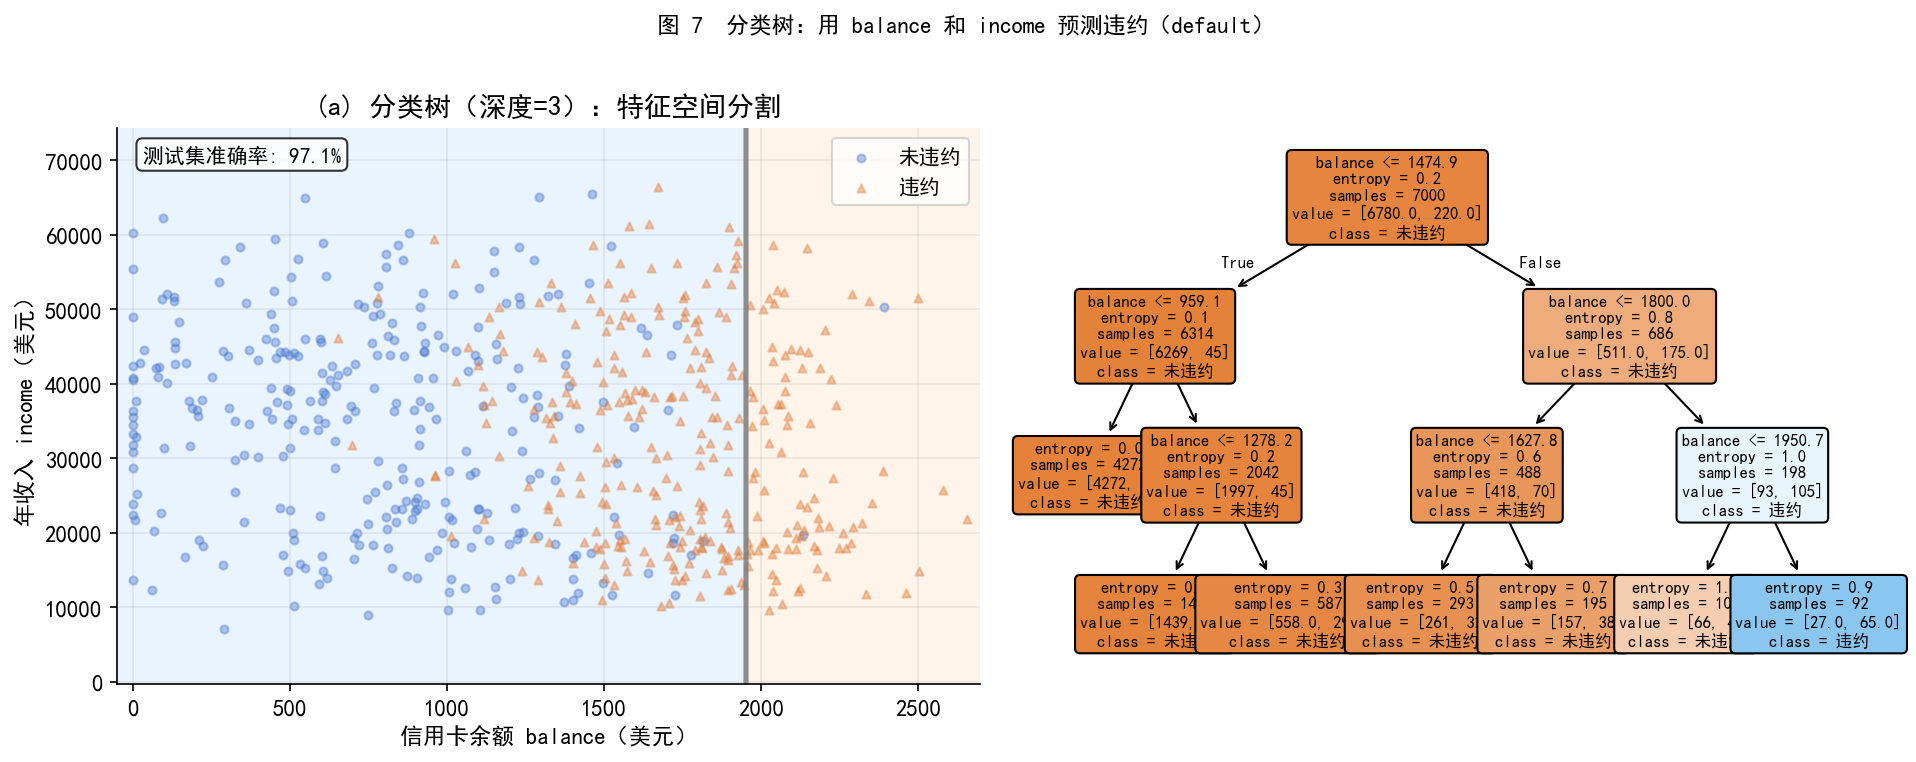

分类树测试集准确率: 0.9707

树的文本结构:
|--- balance <= 1474.92
|   |--- balance <= 959.09
|   |   |--- class: 0
|   |--- balance >  959.09
|   |   |--- balance <= 1278.15
|   |   |   |--- class: 0
|   |   |--- balance >  1278.15
|   |   |   |--- class: 0
|--- balance >  1474.92
|   |--- balance <= 1800.00
|   |   |--- balance <= 1627.84
|   |   |   |--- class: 0
|   |   |--- balance >  1627.84
|   |   |   |--- class: 0
|   |--- balance >  1800.00
|   |   |--- balance <= 1950.70
|   |   |   |--- class: 0
|   |   |--- balance >  1950.70
|   |   |   |--- class: 1



In [18]:
# ------------------------------------------------------------
# 图 07：分类树特征空间分割
# ml_tree_fig07_cls_tree_partition
# ------------------------------------------------------------

X_cls = df[["balance", "income"]].values
y_cls = df["default_bin"].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_cls, y_cls, test_size=0.3, random_state=0
)

cls_tree = DTC(criterion="entropy", max_depth=3, random_state=0)
cls_tree.fit(X_tr, y_tr)

# 网格预测
xx2, yy2 = np.meshgrid(
    np.arange(X_cls[:, 0].min() - 50, X_cls[:, 0].max() + 50, 15),
    np.arange(X_cls[:, 1].min() - 1000, X_cls[:, 1].max() + 1000, 200),
)
Z2 = cls_tree.predict(np.c_[xx2.ravel(), yy2.ravel()])
Z2 = Z2.reshape(xx2.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
cmap2 = ListedColormap(["#cce5ff", "#ffe5cc"])
ax.contourf(xx2, yy2, Z2, alpha=0.4, cmap=cmap2)
ax.contour(xx2, yy2, Z2, colors="gray", linewidths=0.8, alpha=0.6)

for val, color, marker, name in [
    (0, COLOR_NO,      "o", "未违约"),
    (1, COLOR_DEFAULT, "^", "违约"),
]:
    idx = np.where(y_cls == val)[0]
    idx_s = RNG.choice(idx, min(300, len(idx)), replace=False)
    ax.scatter(X_cls[idx_s, 0], X_cls[idx_s, 1],
               c=color, marker=marker, alpha=0.4, s=15, label=name)

ax.set_xlabel("信用卡余额 balance（美元）")
ax.set_ylabel("年收入 income（美元）")
ax.set_title("(a) 分类树（深度=3）：特征空间分割")
ax.legend(fontsize=10)

acc = accuracy_score(y_te, cls_tree.predict(X_te))
ax.text(0.03, 0.97, f"测试集准确率: {acc:.1%}",
        transform=ax.transAxes, va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

ax2 = axes[1]
ax2.set_title("(b) 对应的树结构（entropy 准则）")
plot_tree(
    cls_tree,
    feature_names=["balance", "income"],
    class_names=["未违约", "违约"],
    filled=True, rounded=True,
    fontsize=8, ax=ax2,
    impurity=True, precision=1,
)

fig.suptitle("图 7  分类树：用 balance 和 income 预测违约（default）",
             fontsize=11, y=1.01)
fig.tight_layout()
fig.savefig("./figs/ml_tree_fig07_cls_tree_partition.png", dpi=300, bbox_inches="tight")
fig.savefig("./figs/ml_tree_fig07_cls_tree_partition.svg", bbox_inches="tight")
plt.show()
print(f"分类树测试集准确率: {acc:.4f}")
print("\n树的文本结构:")
print(export_text(cls_tree, feature_names=["balance", "income"]))

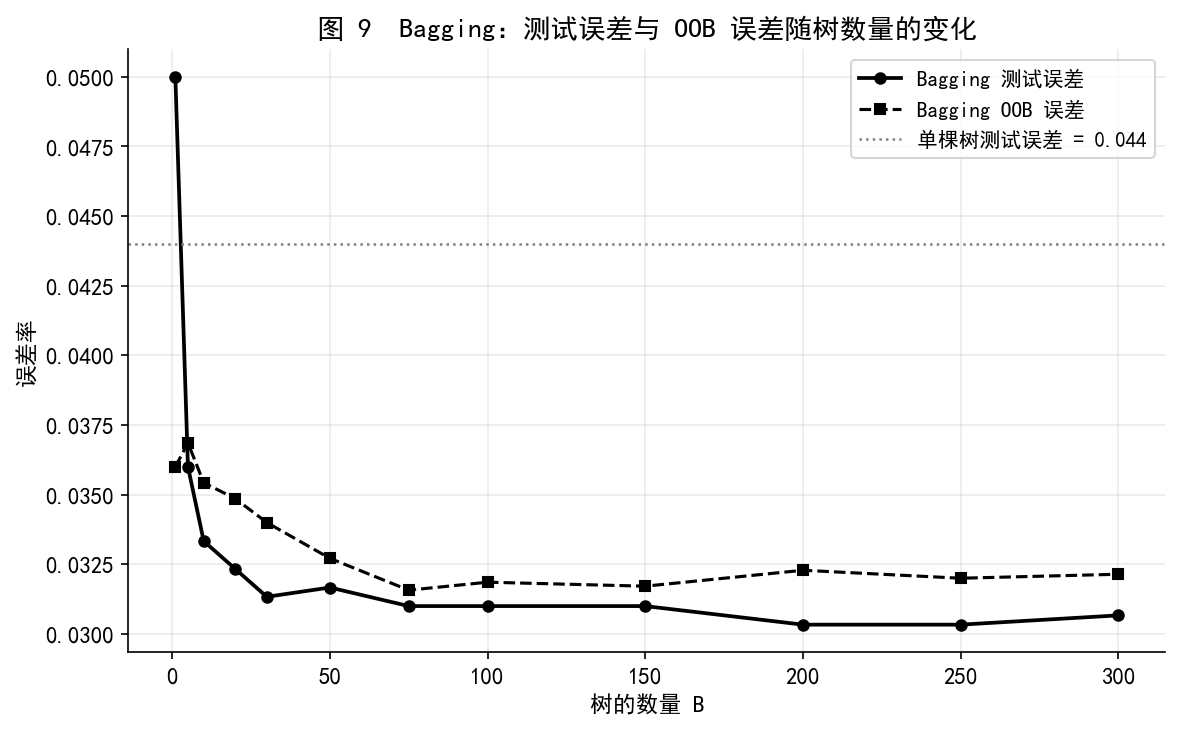

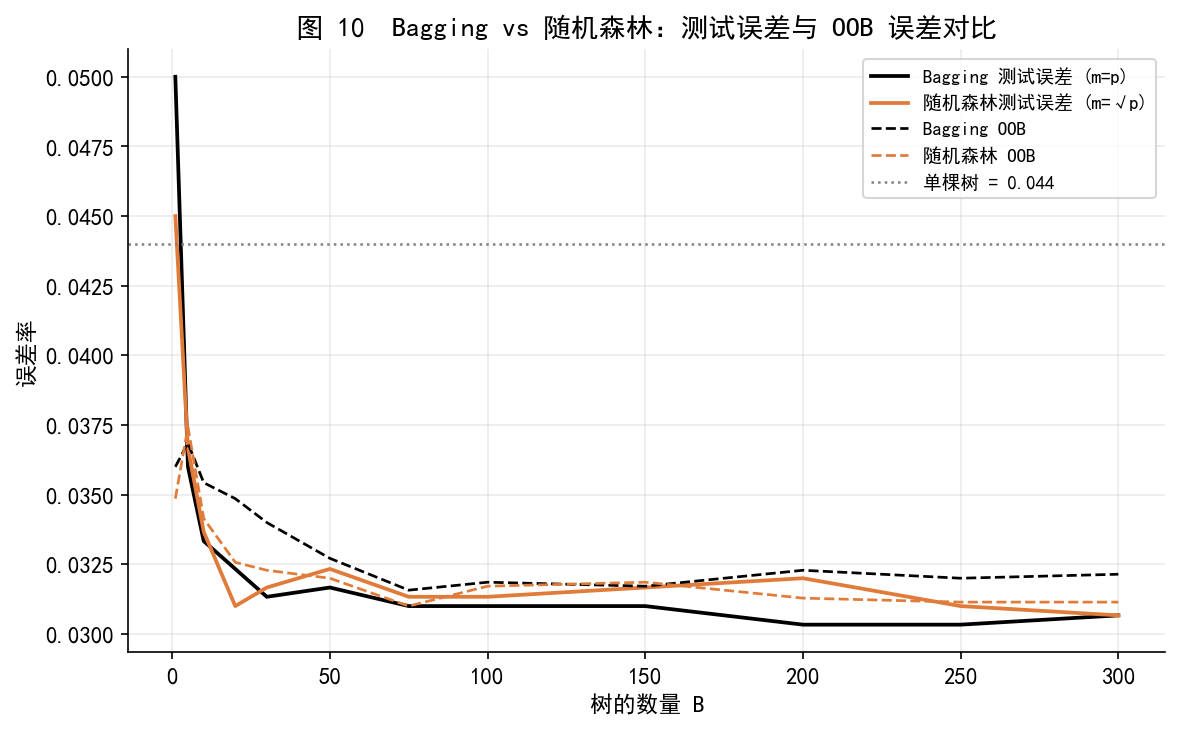

In [19]:
# ------------------------------------------------------------
# 图 09 & 10：Bagging 与随机森林
# ml_tree_fig09_bagging_oob
# ml_tree_fig10_rf_vs_bag
# ------------------------------------------------------------

# 数据准备
X_ens = df[["balance", "income", "student_bin"]].values
y_ens = df["default_bin"].values

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_ens, y_ens, test_size=0.3, random_state=0
)

n_trees_list = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200, 250, 300]

bag_test, bag_oob, rf_test, rf_oob = [], [], [], []

for n in n_trees_list:
    # Bagging：m = p（使用全部特征）
    bag = RFC(
        n_estimators=n, max_features=X_ens.shape[1],
        oob_score=True, random_state=0
    )
    bag.fit(X_tr2, y_tr2)
    bag_test.append(1 - accuracy_score(y_te2, bag.predict(X_te2)))
    bag_oob.append(1 - bag.oob_score_)

    # 随机森林：m = sqrt(p)
    rf = RFC(
        n_estimators=n, max_features="sqrt",
        oob_score=True, random_state=0
    )
    rf.fit(X_tr2, y_tr2)
    rf_test.append(1 - accuracy_score(y_te2, rf.predict(X_te2)))
    rf_oob.append(1 - rf.oob_score_)

# 单棵树的基线误差
single_tree = DTC(random_state=0)
single_tree.fit(X_tr2, y_tr2)
single_err = 1 - accuracy_score(y_te2, single_tree.predict(X_te2))

# 图 09：Bagging OOB 与测试误差
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_trees_list, bag_test, "k-o",  ms=5, lw=1.8, label="Bagging 测试误差")
ax.plot(n_trees_list, bag_oob,  "k--s", ms=5, lw=1.5, label="Bagging OOB 误差")
ax.axhline(single_err, color="gray", lw=1.2, linestyle=":",
           label=f"单棵树测试误差 = {single_err:.3f}")
ax.set_xlabel("树的数量 B")
ax.set_ylabel("误差率")
ax.set_title("图 9  Bagging：测试误差与 OOB 误差随树数量的变化")
ax.legend(fontsize=10)
fig.tight_layout()
fig.savefig("./figs/ml_tree_fig09_bagging_oob.png", dpi=300, bbox_inches="tight")
fig.savefig("./figs/ml_tree_fig09_bagging_oob.svg", bbox_inches="tight")
plt.show()

# 图 10：Bagging vs 随机森林
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_trees_list, bag_test, color="black",      lw=1.8, label="Bagging 测试误差 (m=p)")
ax.plot(n_trees_list, rf_test,  color=COLOR_DEFAULT, lw=1.8, label="随机森林测试误差 (m=√p)")
ax.plot(n_trees_list, bag_oob,  color="black",      lw=1.3, linestyle="--", label="Bagging OOB")
ax.plot(n_trees_list, rf_oob,   color=COLOR_DEFAULT, lw=1.3, linestyle="--", label="随机森林 OOB")
ax.axhline(single_err, color="gray", lw=1.2, linestyle=":",
           label=f"单棵树 = {single_err:.3f}")
ax.set_xlabel("树的数量 B")
ax.set_ylabel("误差率")
ax.set_title("图 10  Bagging vs 随机森林：测试误差与 OOB 误差对比")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig("./figs/ml_tree_fig10_rf_vs_bag.png", dpi=300, bbox_inches="tight")
fig.savefig("./figs/ml_tree_fig10_rf_vs_bag.svg", bbox_inches="tight")
plt.show()

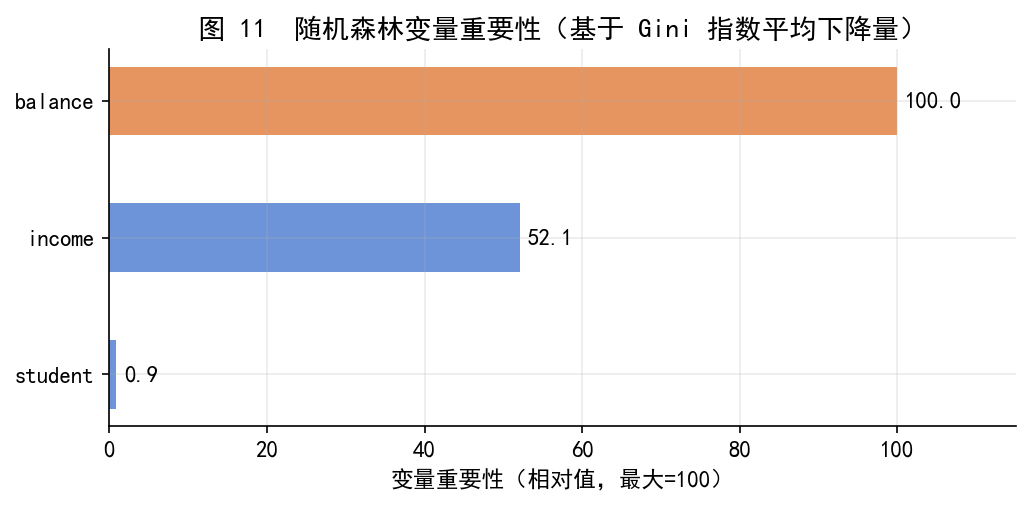

        变量     重要性（相对）
0  balance  100.000000
1   income   52.100414
2  student    0.879244


In [20]:
# ------------------------------------------------------------
# 图 11：变量重要性
# ml_tree_fig11_var_importance
# ------------------------------------------------------------

rf_final = RFC(
    n_estimators=300, max_features="sqrt",
    oob_score=True, random_state=0
)
rf_final.fit(X_tr2, y_tr2)

feat_names = ["balance", "income", "student"]
importances = rf_final.feature_importances_
imp_df = pd.DataFrame({"变量": feat_names, "重要性": importances})
imp_df = imp_df.sort_values("重要性", ascending=True)  # 横向条形图，最重要在顶

# 归一化为相对重要性（最大值=100）
imp_df["重要性（相对）"] = imp_df["重要性"] / imp_df["重要性"].max() * 100

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(
    imp_df["变量"], imp_df["重要性（相对）"],
    color=[COLOR_DEFAULT if v == imp_df["变量"].iloc[-1] else COLOR_NO
           for v in imp_df["变量"]],
    alpha=0.8, height=0.5
)

for bar, val in zip(bars, imp_df["重要性（相对）"]):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}", va="center", fontsize=11)

ax.set_xlabel("变量重要性（相对值，最大=100）")
ax.set_title("图 11  随机森林变量重要性（基于 Gini 指数平均下降量）")
ax.set_xlim(0, 115)
fig.tight_layout()
fig.savefig("./figs/ml_tree_fig11_var_importance.png", dpi=300, bbox_inches="tight")
fig.savefig("./figs/ml_tree_fig11_var_importance.svg", bbox_inches="tight")
plt.show()
print(imp_df[["变量", "重要性（相对）"]].sort_values("重要性（相对）", ascending=False))

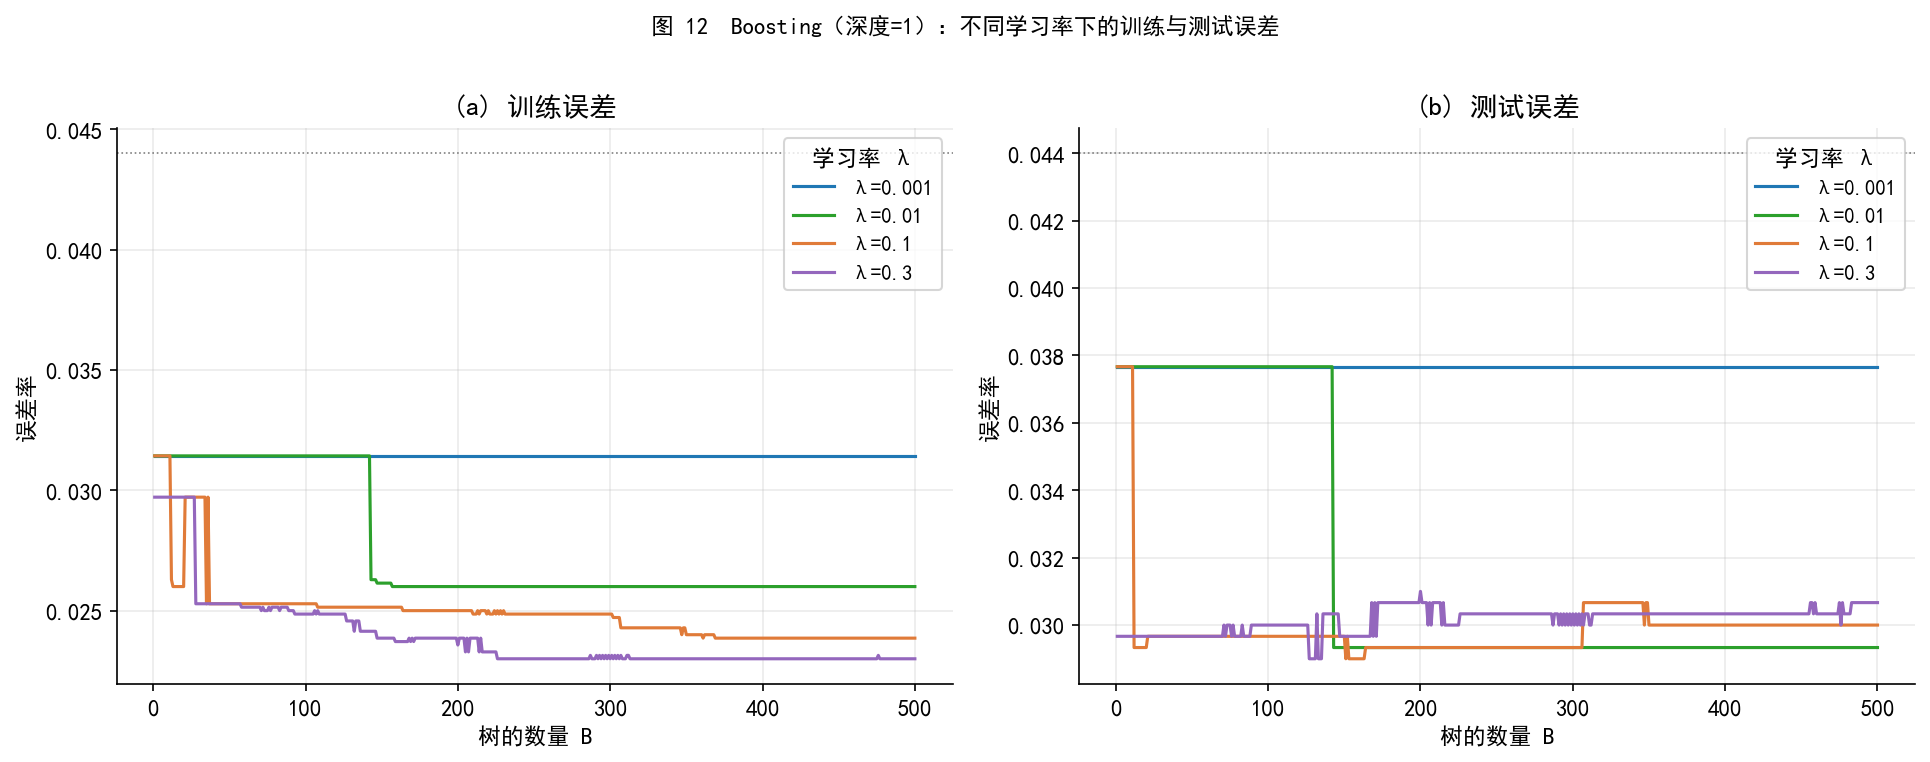

In [21]:
# ------------------------------------------------------------
# 图 12：Boosting — 不同学习率下的训练/测试误差
# ml_tree_fig12_boost_shrinkage
# ------------------------------------------------------------

n_est = 500
lambdas = [0.001, 0.01, 0.1, 0.3]
colors_boost = ["#1f77b4", "#2ca02c", COLOR_DEFAULT, "#9467bd"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for lam, col in zip(lambdas, colors_boost):
    gbc = GBC(
        n_estimators=n_est,
        learning_rate=lam,
        max_depth=1,       # 使用深度为 1 的 stump
        random_state=0,
        subsample=1.0,
    )
    gbc.fit(X_tr2, y_tr2)

    # 训练误差（随迭代次数）
    train_err_path = []
    test_err_path  = []
    for y_pred_stage in gbc.staged_predict(X_tr2):
        train_err_path.append(1 - accuracy_score(y_tr2, y_pred_stage))
    for y_pred_stage in gbc.staged_predict(X_te2):
        test_err_path.append(1 - accuracy_score(y_te2, y_pred_stage))

    iters = np.arange(1, n_est + 1)
    axes[0].plot(iters, train_err_path, color=col, lw=1.5, label=f"λ={lam}")
    axes[1].plot(iters, test_err_path,  color=col, lw=1.5, label=f"λ={lam}")

for ax, title in zip(axes, ["(a) 训练误差", "(b) 测试误差"]):
    ax.set_xlabel("树的数量 B")
    ax.set_ylabel("误差率")
    ax.set_title(title)
    ax.legend(fontsize=10, title="学习率 λ")
    ax.axhline(single_err, color="gray", lw=0.8, linestyle=":")

fig.suptitle("图 12  Boosting（深度=1）：不同学习率下的训练与测试误差",
             fontsize=11, y=1.01)
fig.tight_layout()
fig.savefig("./figs/ml_tree_fig12_boost_shrinkage.png", dpi=300, bbox_inches="tight")
fig.savefig("./figs/ml_tree_fig12_boost_shrinkage.svg", bbox_inches="tight")
plt.show()

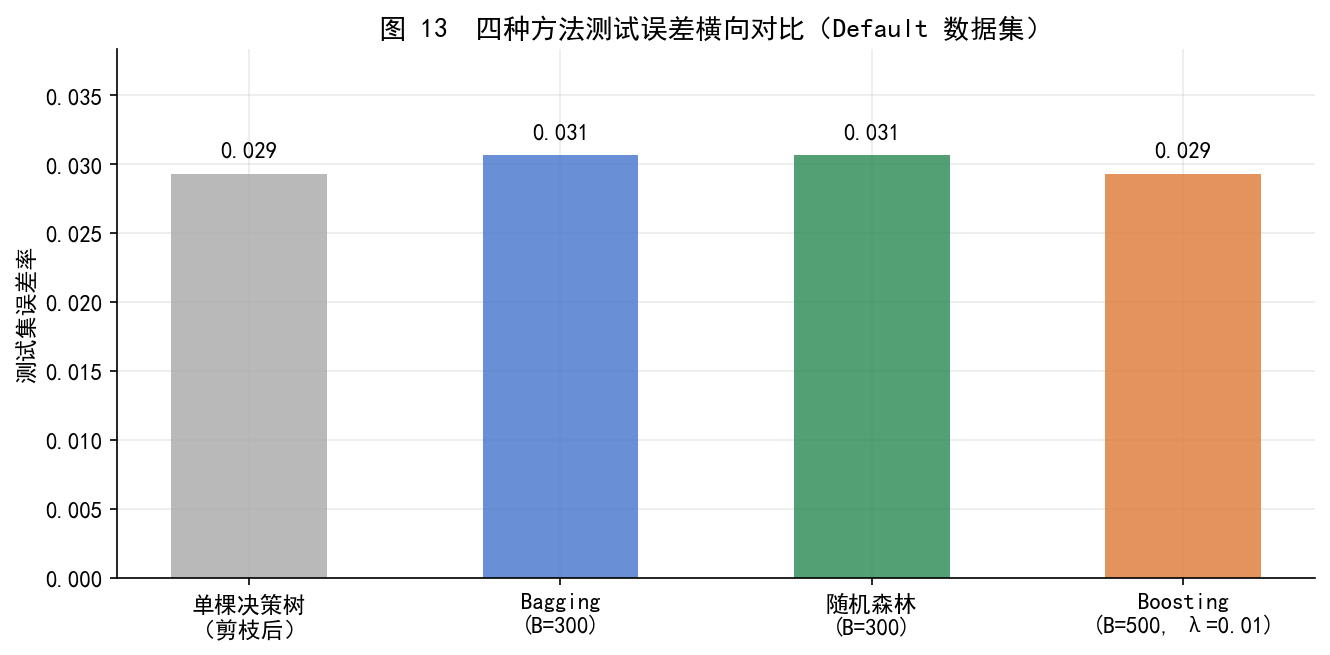


方法对比汇总：
  单棵决策树 （剪枝后）                   : 0.0293
  Bagging (B=300)               : 0.0307
  随机森林 (B=300)                  : 0.0307
  Boosting (B=500, λ=0.01)      : 0.0293


In [22]:
# ------------------------------------------------------------
# 图 13：四种方法测试误差横向对比
# ml_tree_fig13_method_compare
# ------------------------------------------------------------

# 单棵分类树（最优剪枝）
ccp_path2 = DTC(random_state=0).fit(X_tr2, y_tr2).cost_complexity_pruning_path(X_tr2, y_tr2)
grid2 = GridSearchCV(
    DTC(random_state=0),
    {"ccp_alpha": ccp_path2.ccp_alphas[:-1]},
    cv=5, scoring="accuracy"
).fit(X_tr2, y_tr2)
single_best_err = 1 - accuracy_score(y_te2, grid2.best_estimator_.predict(X_te2))

# Bagging（B=300）
bag300 = RFC(n_estimators=300, max_features=X_ens.shape[1], random_state=0)
bag300.fit(X_tr2, y_tr2)
bag300_err = 1 - accuracy_score(y_te2, bag300.predict(X_te2))

# 随机森林（B=300）
rf300 = RFC(n_estimators=300, max_features="sqrt", random_state=0)
rf300.fit(X_tr2, y_tr2)
rf300_err = 1 - accuracy_score(y_te2, rf300.predict(X_te2))

# Boosting（B=500, λ=0.01）
boost_best = GBC(n_estimators=500, learning_rate=0.01, max_depth=1, random_state=0)
boost_best.fit(X_tr2, y_tr2)
boost_err = 1 - accuracy_score(y_te2, boost_best.predict(X_te2))

methods = ["单棵决策树\n（剪枝后）", "Bagging\n(B=300)", "随机森林\n(B=300)", "Boosting\n(B=500, λ=0.01)"]
errors  = [single_best_err, bag300_err, rf300_err, boost_err]
colors_cmp = ["#aaaaaa", COLOR_NO, COLOR_TREE, COLOR_DEFAULT]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(methods, errors, color=colors_cmp, alpha=0.82, width=0.5, zorder=2)

for bar, val in zip(bars, errors):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.001, f"{val:.3f}",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax.set_ylabel("测试集误差率")
ax.set_title("图 13  四种方法测试误差横向对比（Default 数据集）")
ax.set_ylim(0, max(errors) * 1.25)
fig.tight_layout()
fig.savefig("./figs/ml_tree_fig13_method_compare.png", dpi=300, bbox_inches="tight")
fig.savefig("./figs/ml_tree_fig13_method_compare.svg", bbox_inches="tight")
plt.show()

print("\n方法对比汇总：")
for m, e in zip(methods, errors):
    print(f"  {m.replace(chr(10), ' '):30s}: {e:.4f}")